## Read output files

In [189]:
import awkward as ak
import numpy as np
import uproot
import os

In [190]:
basedir = {
    c: '../condor/output/mc/2018/'+c for c in os.listdir('../condor/output/mc/2018/')
}
filepath={c: [] for c in basedir}
for c in basedir:
    for (current_path, dirs, files) in os.walk(basedir[c]):
        for f in files:
            if f.endswith('.parq'):
                filepath[c].append(os.path.join(current_path, f))

filepath

{'GJets': ['../condor/output/mc/2018/GJets/GJets_HT-200To400/0.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/1.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/10.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/11.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/12.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/13.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/14.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/15.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/16.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/17.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/18.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/19.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/2.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/20.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/21.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-200To400/22.parq',
  

In [191]:
events = {
    k: [] for k in filepath
}
for k, v in filepath.items():
    for f in v:
        array = ak.from_parquet(f)
        if len(array)>0:
            events[k].append(array)
    events[k] = ak.concatenate(events[k], axis=0)

events

{'GJets': <Array [{AK8jet_phi: [, ... ] type='655799 * {"AK8jet_phi": option[var * float32...'>,
 'QCD': <Array [{AK8jet_phi: [, ... ] type='26857 * {"AK8jet_phi": option[var * float32]...'>,
 'TTGJets': <Array [{AK8jet_eta: [, ... ] type='9715 * {"AK8jet_eta": option[var * float32],...'>,
 'WJetsToQQ': <Array [{AK8jet_eta: [, ... ] type='13538 * {"AK8jet_eta": option[var * float32]...'>,
 'ZJetsToQQ': <Array [{AK8jet_msoftdrop: [, ... ] type='3731 * {"AK8jet_msoftdrop": option[var...'>,
 'ZpToHGamma': <Array [{AK8jet_phi: [, ... event_weight: 1.2}] type='174263 * {"AK8jet_phi": op...'>}

In [192]:
BKG = set(events.keys()) - set('ZpToHGamma')
BKG

{'GJets', 'QCD', 'TTGJets', 'WJetsToQQ', 'ZJetsToQQ', 'ZpToHGamma'}

In [193]:
for m in [1000, 2000, 3000]:
    cut = ak.flatten(
        (events['ZpToHGamma']["gen_Zp_mass"] > m-10) &
        (events['ZpToHGamma']["gen_Zp_mass"] < m+10)
    )
    events[f'ZpToHGamma_{m}'] = events['ZpToHGamma'][cut]

del events['ZpToHGamma']

## Start plotting

In [194]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['cyan', 'darkorange', 'HotPink', 'darkviolet', 'SlateGray', 'red', 'blue', 'green', 'black', 'LightSkyBlue'])

In [195]:
set(events['ZpToHGamma_1000'].event_genWeight)

{-1.0, 0.9800999760627747, 0.9900000095367432, 1.0}

In [196]:
weight={k: events[k].event_weight for k in events}

In [197]:
def plot(arrays, weight, plot_name: str, x_name: str, cuts=None, year=2018, bins=40, x_min=0, x_max=2000, density=False, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    color={'ZpToHGamma_1000': 'red', 'ZpToHGamma_2000': 'blue', 'ZpToHGamma_3000': 'green'}
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
        
    def flow(hist: bh.Histogram, overflow: bool=True, underflow=False):
        h, var = hist.view(flow=(overflow|underflow)).value, hist.view(flow=(overflow|underflow)).variance
        if overflow: ## h, var also include underflow bins but in plots usually no underflow data
            ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
            h[-2]+=h[-1]; var[-2]+=var[-1]
        if underflow:
            h[1]+=h[0]; var[1]+=var[0]
        if overflow or underflow:
            h = h[1:-1]; var = var[1:-1]
        return h, var
            
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9,9))
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.1)
    ax = f.add_subplot(gs[0])
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax, lumi=59.83, fontsize=18)
    ## Ratio panel
    ax1 = f.add_subplot(gs[1]); 
    ax1.grid()
    
    ## analyze
    bkg = {'h': {}, 'var': {}}
    sig = {'h': {}, 'var': {}}
    
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if 'delta_phi' in plot_name:
            values = np.min([v, 2*np.pi-v], axis=0)
        values = ak.fill_none(v, -999)
        
        hist.fill(values, weight=weight[k])
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        if k in BKG: 
            bkg['h'][k] = h
            bkg['var'][k] = var
        else:
            sig['h'][k] = h
            sig['var'][k] = var
        
    ## plot
    ax1.plot([x_min,x_max], [1,1], 'black')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 
    hep.histplot(list(bkg['h'].values()), bins=hist.axes[0].edges, label=list(bkg['h'].keys()), histtype='fill', density=density, stack=True, linewidth=2, ax=ax)
    bkg_h = np.sum(list(bkg['h'].values()), axis=0)
    bkg_var = np.sum(list(bkg['var'].values()), axis=0)
    for (k,v) in sig['h'].items():
        hep.histplot(v*10, bins=hist.axes[0].edges, yerr=np.sqrt(sig['var'][k]*10), label=k+r'$\times 10$', histtype='step', density=density, stack=False, linewidth=2.5, ax=ax)
        y = v/np.sqrt(bkg_h+1)
        yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
        hep.histplot(y, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=yerr, label=k, histtype='errorbar', density=density, stack=True, ax=ax1, color=color[k])

    ## axises
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ax.get_ylim()[1]*1.2)
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)
    ax1.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax1.set_ylabel(r'$S/\sqrt{B+1}$', ha='center', fontsize=20)
    ax1.set_xlim(x_min,x_max)
    ax1.set_ylim(0.1, 100)
    ax1.ticklabel_format(useOffset=False, style='plain')
    ax1.set_yscale('log')
    ax1.tick_params(axis='both', which='major', labelsize=16)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=16)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+plot_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [198]:
print(events['ZpToHGamma_1000'].fields)
events.keys()

['AK8jet_phi', 'AK8jet_eta', 'AK8jet_pt', 'AK8jet_mass', 'AK8jet_msoftdrop', 'photon_pt', 'photon_mass', 'photon_phi', 'photon_eta', 'event_MET_pt', 'event_genWeight', 'photon-jet_pt', 'photon-jet_mass', 'photon-jet_phi', 'photon-jet_eta', 'photon-jet_deltaR', 'gen_Zp_phi', 'gen_Zp_eta', 'gen_Zp_pt', 'gen_Zp_mass', 'gen_Zp_pdgId', 'gen_H_phi', 'gen_H_eta', 'gen_H_pt', 'gen_H_mass', 'gen_H_pdgId', 'gen_a_phi', 'gen_a_eta', 'gen_a_pt', 'gen_a_mass', 'gen_a_pdgId', 'gen_WW_phi', 'gen_WW_eta', 'gen_WW_pt', 'gen_WW_mass', 'gen_WW_pdgId', 'gen_WW_childs_phi', 'gen_WW_childs_eta', 'gen_WW_childs_pt', 'gen_WW_childs_mass', 'gen_WW_childs_pdgId', 'gen_H_a', 'gen_deltaR_H_a', 'gen_HWW_decay_mode', 'gen_HWW_a', 'gen_MET_pt', 'event_weight']


dict_keys(['GJets', 'QCD', 'TTGJets', 'WJetsToQQ', 'ZJetsToQQ', 'ZpToHGamma_1000', 'ZpToHGamma_2000', 'ZpToHGamma_3000'])

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


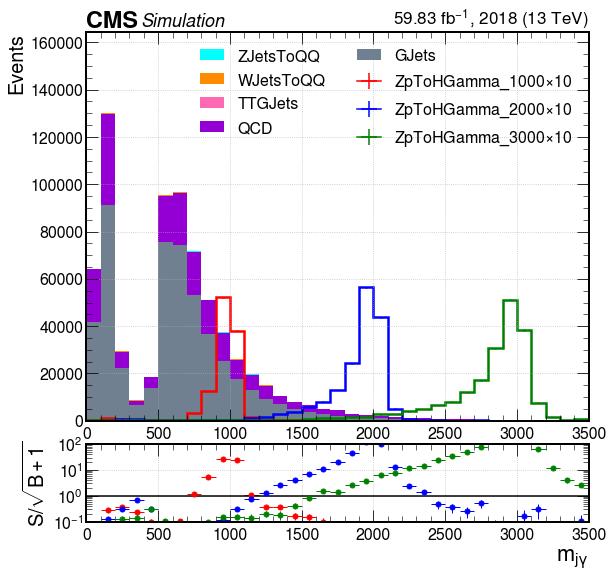

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


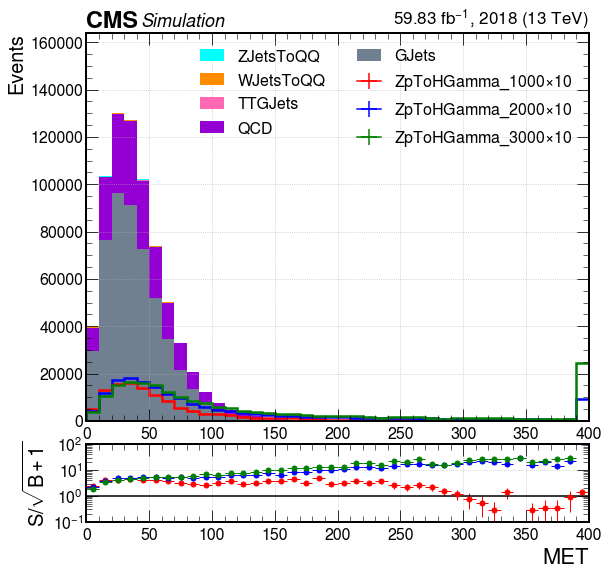

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


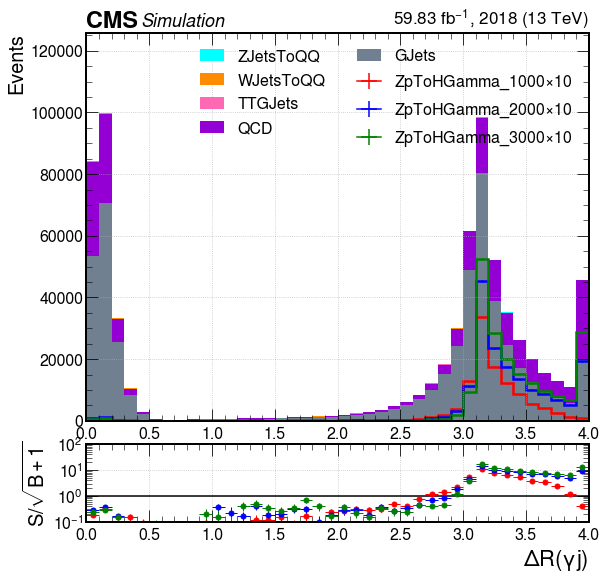

In [199]:
arrays={k: events[k]['photon-jet_mass'] for k in events}
plot(arrays, x_name=r'$m_{j\gamma}$', plot_name='photon-jet_mass', x_max=3500, bins=35, weight=weight)
arrays={k: events[k]['event_MET_pt'] for k in events}
plot(arrays, x_name='MET', plot_name='event_MET_pt', x_max=400, bins=40, weight=weight)
arrays={k: events[k]['photon-jet_deltaR'] for k in events}
plot(arrays, x_name=r'$\Delta R(\gamma j)$', plot_name='photon-jet_deltaR', x_max=4, bins=40, weight=weight)

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


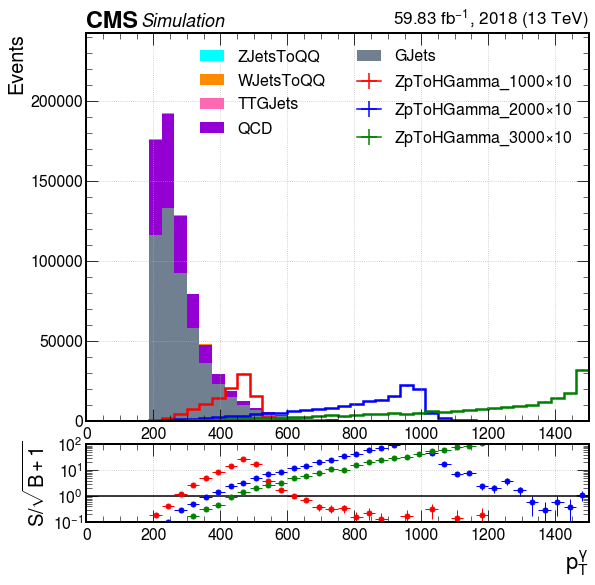

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


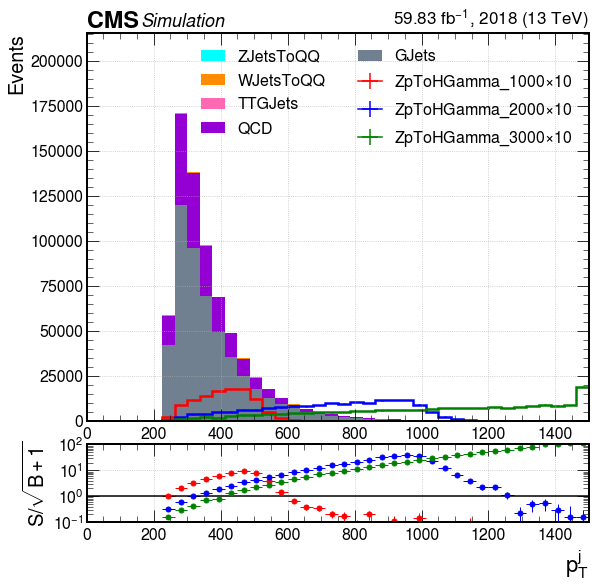

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


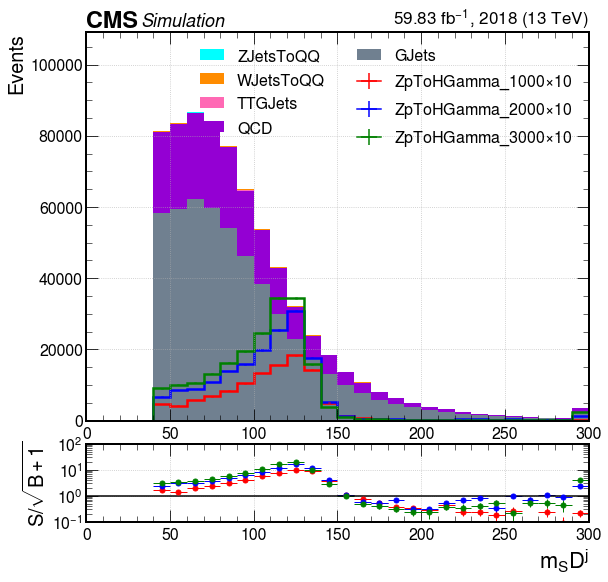

In [200]:
leading_photon = {k: ak.argmax(events[k].photon_pt, axis=1, keepdims=True) for k in events}
heaviest_AK8jet = {k: ak.argmax(events[k].AK8jet_msoftdrop, axis=1, keepdims=True) for k in events}

arrays={k: ak.flatten(events[k].photon_pt[leading_photon[k]]) for k in events}
plot(arrays, plot_name='photon_pt', x_name=r'$p_T^{\gamma}$', x_max=1500, bins=40, weight=weight)
arrays={k: ak.flatten(events[k].AK8jet_pt[heaviest_AK8jet[k]]) for k in events}
plot(arrays, plot_name='AK8jet_pt', x_name=r'$p_T^{j}$', x_max=1500, bins=40, weight=weight)
arrays={k: ak.flatten(events[k].AK8jet_msoftdrop[heaviest_AK8jet[k]]) for k in events}
plot(arrays, plot_name='AK8jet_msoftdrop', x_name=r'$m_SD^{j}$', x_max=300, bins=30, weight=weight)

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in multiply
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


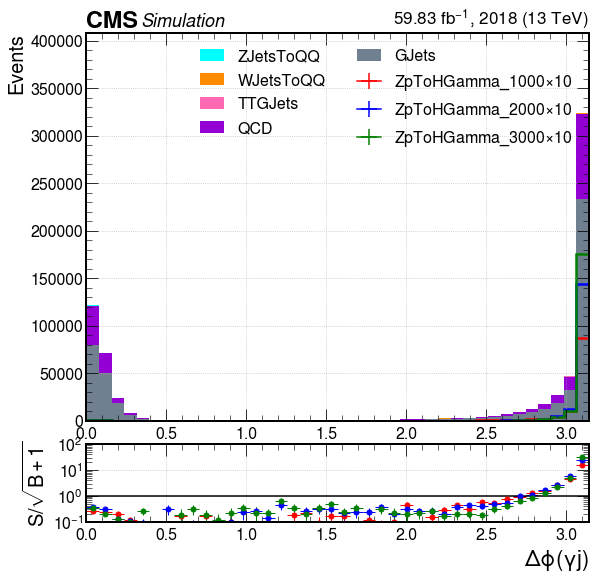

/tmp/dfu/ipykernel_18302/1624279973.py:60: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


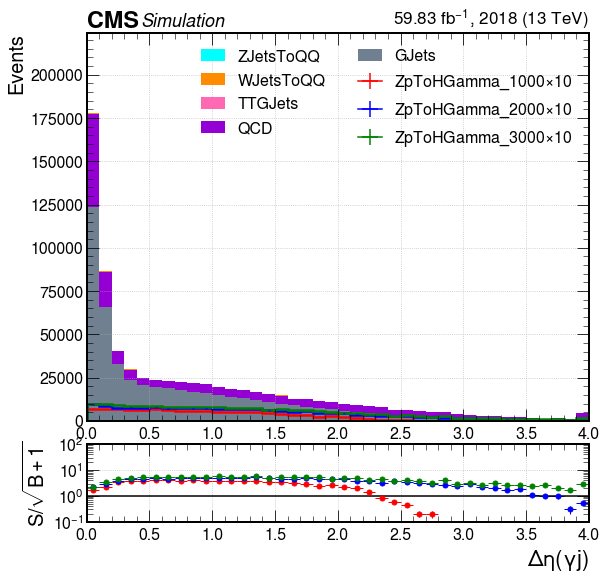

In [201]:
leading_photon = {k: ak.argmax(events[k].photon_pt, axis=1, keepdims=True) for k in events}
heaviest_AK8jet = {k: ak.argmax(events[k].AK8jet_msoftdrop, axis=1, keepdims=True) for k in events}

arrays={k: abs(ak.flatten(events[k].photon_phi[leading_photon[k]]) - ak.flatten(events[k].AK8jet_phi[heaviest_AK8jet[k]])) for k in events}
plot(arrays, plot_name='photon-jet_delta_phi', x_name=r'$\Delta \phi(\gamma j)$', x_max=np.pi, bins=40, weight=weight)
arrays={k: abs(ak.flatten(events[k].photon_eta[leading_photon[k]]) - ak.flatten(events[k].AK8jet_eta[heaviest_AK8jet[k]])) for k in events}
plot(arrays, plot_name='photon-jet_delta_eta', x_name=r'$\Delta \eta(\gamma j)$', x_max=4, bins=40, weight=weight)

In [202]:
arrays={k: abs(ak.flatten(events[k].photon_phi[leading_photon[k]]) - ak.flatten(events[k].AK8jet_phi[heaviest_AK8jet[k]])) for k in events}

In [203]:
np.min(np.min([arrays['ZpToHGamma_1000'], 2*np.pi-arrays['ZpToHGamma_1000']], axis=0))

0.0009765625

IndexError: list index out of range

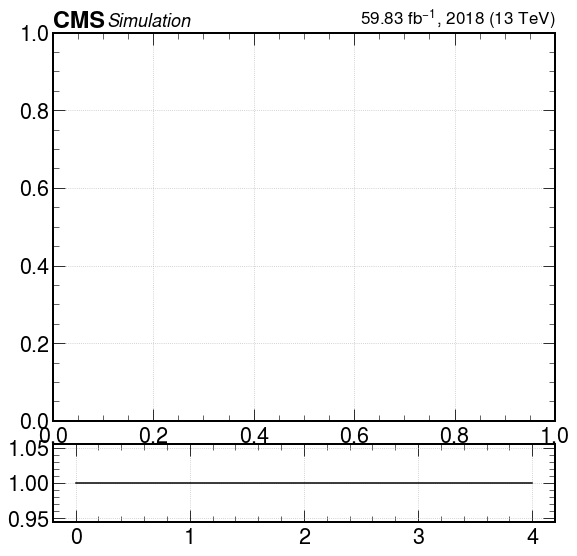

In [204]:
arrays={k: events[k].gen_deltaR_H_a for k in events if 'ZpToHGamma' in k}
plot(arrays, plot_name='gen_deltaR_H_a', x_name=r'$\Delta R^{gen}(\gamma j)$', x_max=4, bins=40, weight=weight)